### Creating ML Model for final Dataset

In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
BASE_DATA_PATH = "../Dataset/final_data.parquet"

In [3]:
df = pd.read_parquet(BASE_DATA_PATH)
df.head()

,flow iat mean,flow iat std,flow duration,packet length std,avg packet size,total fwd packets,down/up ratio,iat_cv,prot_6,prot_17,label
0,1.309639e-04,4.457724e-04,0.003536,0.088965,0.062402,0.000078,0.00000,0.040039,True,False,0
1,8.483972e-04,2.152960e-03,0.002545,0.023615,0.051627,0.000005,0.03125,0.029849,False,True,0
2,8.666500e-04,0.000000e+00,0.000867,0.007931,0.036815,0.000000,0.03125,0.000000,False,True,0
3,5.277778e-07,8.139906e-07,0.000002,0.003241,0.026627,0.000005,0.03125,0.018432,False,True,0
4,7.474583e-04,1.896342e-03,0.002242,0.011692,0.035274,0.000005,0.03125,0.029842,False,True,0


In [4]:
X = df.drop(columns=["label"])
y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['label']), df['label'], test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [7]:
model.score(X_test, y_test)

0.8585

In [8]:
def create_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [16]:
def create_classification_report(model, X_test, y_test):
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred)
    print(report)
    return report

In [17]:
model_report = create_classification_report(model, X_test, y_test)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86     10035
           1       0.88      0.83      0.85      9965

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



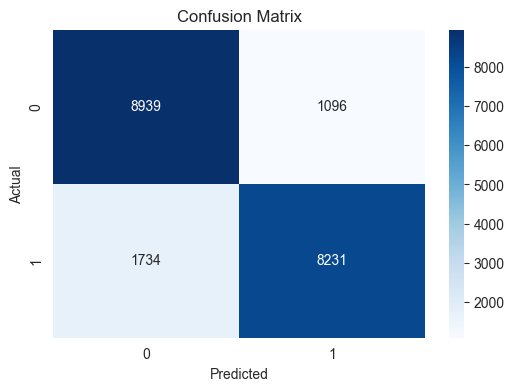

In [11]:
create_confusion_matrix(model, X_test, y_test)

In [12]:
## Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
dt_report = create_classification_report(dt_model, X_test, y_test)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10035
           1       0.99      0.99      0.99      9965

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



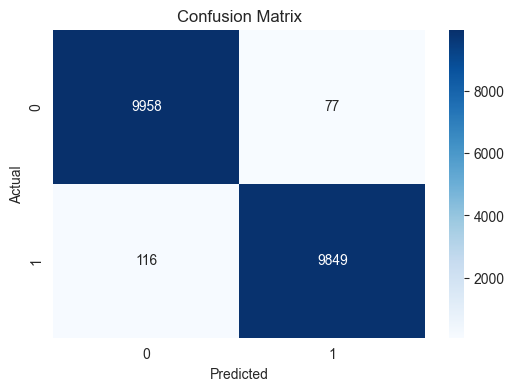

In [15]:
create_confusion_matrix(dt_model, X_test, y_test)

In [19]:
## Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
rf_report = create_classification_report(rf_model, X_test, y_test)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10035
           1       0.99      0.99      0.99      9965

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



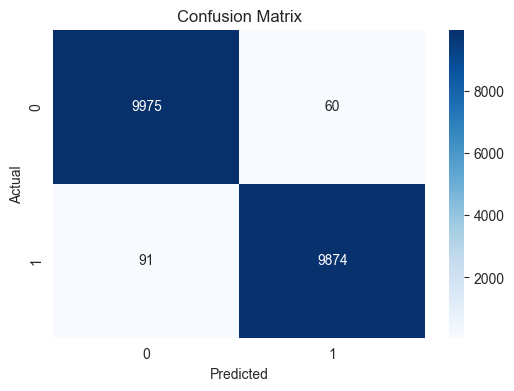

In [21]:
create_confusion_matrix(rf_model, X_test, y_test)

##### Though Random Forest Classifier is performing best, but it is highly complex and may not be suitable for real-time predictions. Decision Tree Classifier is simpler and faster, making it a better choice for our use case. We will proceed with Decision Tree Classifier for our final model.

In [22]:
dt_model.get_depth()

34

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
} 

In [24]:
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 10}


In [25]:
best_dt_model = grid_search.best_estimator_

In [26]:
best_dt_report = create_classification_report(best_dt_model, X_test, y_test)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10035
           1       0.99      0.99      0.99      9965

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



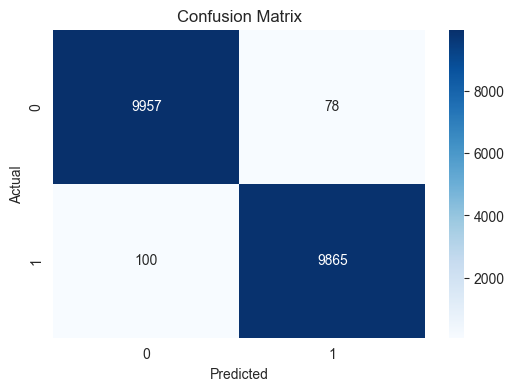

In [27]:
create_confusion_matrix(best_dt_model, X_test, y_test)

In [30]:
### Saaving best supervised model for future use
import pickle 
with open('../Models/best_dt_model.pkl', 'wb') as f:
    pickle.dump(best_dt_model, f)